# IAA (Krippendorff's $\alpha$)

In [16]:
import json
import numpy as np
import os

from krippendorff import alpha
from numpy import dtype, ndarray
from typing import Any

INPUT_DATA_PATH = os.path.join("../data", "students_teacher_gold.json")

In [ ]:
def get_data(input_data_path: str = INPUT_DATA_PATH) -> list[list[dict[str, Any]]]:
    with open(input_data_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return [item.get("teacher_annotation_data", []) for item in data]

def get_annotators(input_data_path: str = INPUT_DATA_PATH) -> list[str]:
    data = get_data(input_data_path)
    
    annotators = set()
    for annotations in data:
        for annotation in annotations:
            id = annotation.get("annotator_id")alpha
            if id is not None:
                annotators.add(id)

    return sorted(list(annotators))

def get_n_annotated_items(input_data_path: str = INPUT_DATA_PATH) -> int:
    return len(get_data(input_data_path))

def load_data_matrix(input_path: str = INPUT_DATA_PATH) -> ndarray[tuple[int, int], dtype[Any]]:
    """
    Load the gold JSON data and convert it into a matrix, where each row corresponds to an annotator and each column corresponds to an annotated item. The matrix contains the numeric representation of the annotations (1 for model A, -1 for model B, 0 for ties), and fills missing annotations with `NaN` values.
    The output matrix can be used to compute Krippendorff's alpha.
    """
    data = get_data(input_path)
    
    n_annotated_items = get_n_annotated_items(input_path)
    annotators = get_annotators(input_path)
    
    annotator_to_idx = {annotator: idx for idx, annotator in enumerate(annotators)}
    
    map_annotation_to_numeric = {
        "a": 1,
        "both_equal": 0,
        "b": -1
    }

    out_matrix = np.full((len(annotators), n_annotated_items), np.nan)
    
    for i, item in enumerate(data):
        for annotation in item:
            annotator_id = annotation.get("annotator_id")
            label = map_annotation_to_numeric.get(annotation.get("preferred_model", ""), None)
            
            if annotator_id is not None and annotator_id in annotator_to_idx and label is not None:
                out_matrix[annotator_to_idx[annotator_id], i] = label
    
    return out_matrix

In [26]:
print("Krippendorff's alpha:", alpha(load_data_matrix(INPUT_DATA_PATH), value_domain=[-1, 0, 1], level_of_measurement="ordinal"))

Krippendorff's alpha: 0.16307012571110313


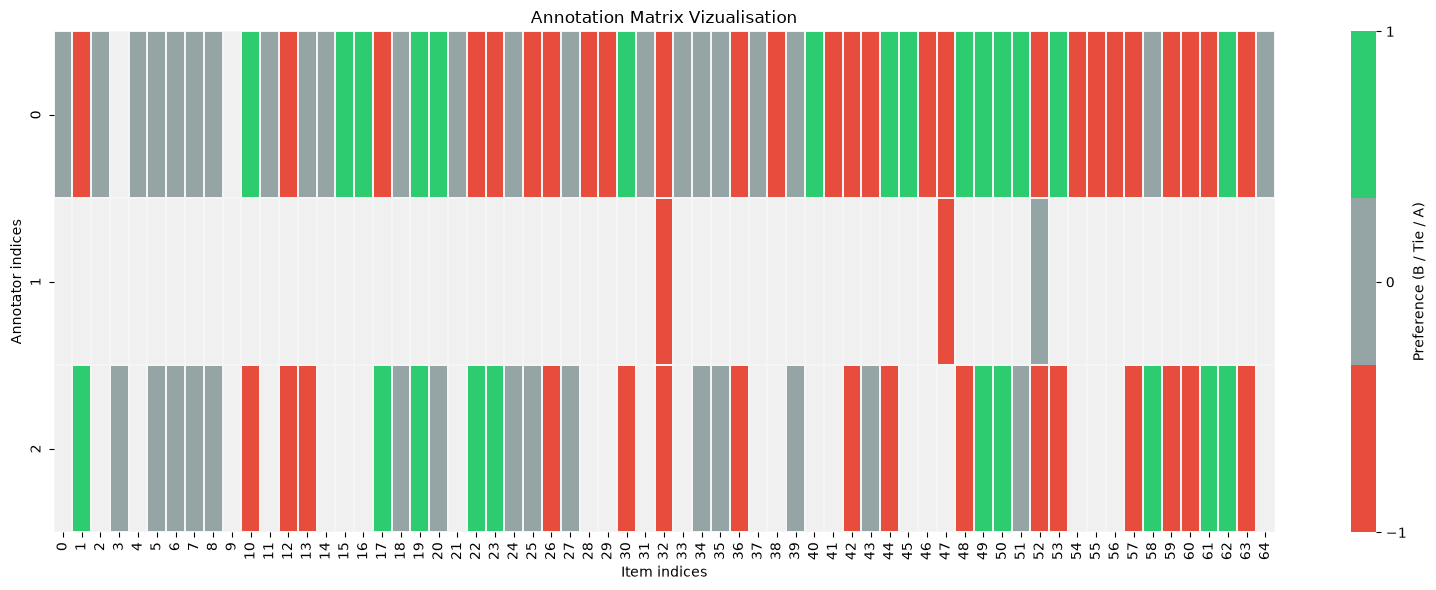

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_matrix(out_matrix):
    plt.figure(figsize=(16, 6))
    
    cmap = sns.color_palette(["#e74c3c", "#95a5a6", "#2ecc71"])
    
    ax = sns.heatmap(
        out_matrix,
        cmap=cmap,
        cbar_kws={'ticks': [-1, 0, 1], 'label': 'Preference (B / Tie / A)'},
        linewidths=0.05,
        linecolor='whitesmoke'
    )
    
    ax.set_facecolor('#f0f0f0') 
    
    plt.title("Annotation Matrix Vizualisation")
    plt.xlabel("Item indices")
    plt.ylabel("Annotator indices")
    
    plt.tight_layout()
    plt.show()

visualize_matrix(load_data_matrix())

When we look at agreement between expert annotators, it appears there is a high level of disagreement among them (Krippendorff's $\alpha \approx 0.163$).

This suggests that the task may be inherently subjective (which it likely is) or that the guidelines provided to the annotators were perhaps not clear enough.

Computing Krippendorff's $\alpha$ on finer-grained categories may yield more precise information on that regard.